# DATA PROFILING AND DATA QUALITY CHECKS

## Key diagrams

# Applications

**Running data quality checks and orientation for the applications dataset**

---

## Data orientation

### Purpose
1. Understand what each row represents
2. Understand what columns are in the dataset
3. Understand any data quality and completeness faults
4. Check for dupicates
5. Check whether values are plausible
6. Identify where it can be linked to other datasets

# Profiling (Applications) - what does the data look like

In [17]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [18]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")

applications = pd.read_csv(DATA_DIR / "applications.csv")

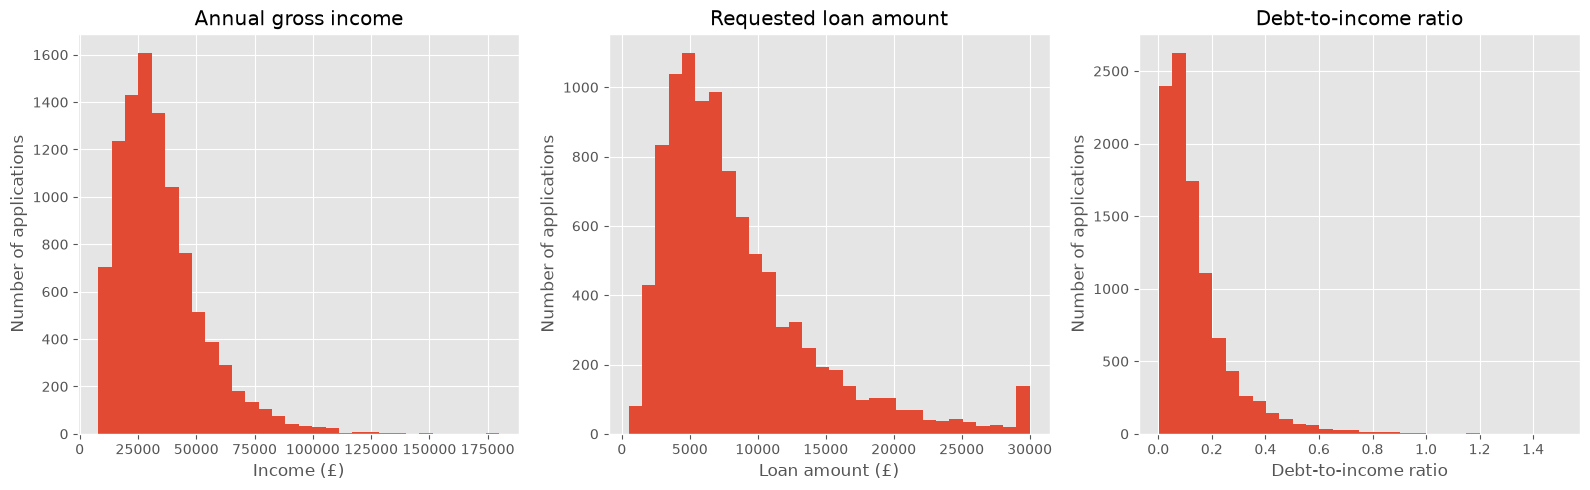

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(applications["annual_gross_income"], bins=30)
axes[0].set_title("Annual gross income")
axes[0].set_xlabel("Income (£)")
axes[0].set_ylabel("Number of applications")

axes[1].hist(applications["requested_loan_amount"], bins=30)
axes[1].set_title("Requested loan amount")
axes[1].set_xlabel("Loan amount (£)")
axes[1].set_ylabel("Number of applications")

axes[2].hist(applications["debt_to_income_ratio"], bins=30)
axes[2].set_title("Debt-to-income ratio")
axes[2].set_xlabel("Debt-to-income ratio")
axes[2].set_ylabel("Number of applications")

plt.tight_layout()
plt.show()

I can already see that there are two potential link variables: account_id and customer_id

# Profiling - applications

In [20]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")

applications = pd.read_csv(DATA_DIR / "applications.csv")

applications.head()

,account_id,customer_id,customer_name,address_line_1,postcode,date_of_birth,age_at_application,application_date,employment_status,employment_tenure_months,...,prior_customer_flag,device_verification_result,contact_verification_result,credit_history_months,active_credit_accounts,revolving_utilisation,recent_credit_searches,historic_defaults,historic_arrears,electoral_roll_match
0,ACC-10000000,CUS-20000000,Aisha Foster,218 Station Lane,NG14 9VP,1981-06-19,42,2024-06-02,part_time,26,...,0,pass,pass,88,5,0.6041,1,0,0,full
1,ACC-10000001,CUS-20000001,Oliver Clarke,9 Kingfisher Way,LS27 2AP,1993-10-12,29,2023-05-29,retired,100,...,0,refer,pass,86,3,0.2484,2,0,0,full
2,ACC-10000002,CUS-20000002,Isla Davies,181 Oak Road,CF29 7JL,1992-08-16,30,2023-04-11,self_employed,50,...,1,pass,pass,57,1,0.0963,2,0,0,partial
3,ACC-10000003,CUS-20000003,Maya Roberts,191 Station Lane,B3 8NV,1990-06-04,33,2023-12-27,retired,24,...,0,refer,pass,147,2,0.7441,0,0,1,full
4,ACC-10000004,CUS-20000004,Priya Khan,205 Kingfisher Way,RG28 6EP,1990-12-07,33,2024-04-08,employed,25,...,1,pass,pass,135,2,0.3473,2,0,1,none


In [21]:
# 1. What is one row?
print("One row represents one loan application / account.")
print(f"\nRows: {len(applications):,}")
print(f"Columns: {len(applications.columns):,}")

# 2. What columns and data types does it contain?
print("\n--- Columns and data types ---")
print(applications.dtypes)

# 3. Is it complete?
print("\n--- Missing values ---")
missing = pd.DataFrame({
    "missing_count": applications.isna().sum(),
    "missing_percent": (applications.isna().mean() * 100).round(2)
})
print(missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False))

# 4. Is it unique where it should be?
print("\n--- Duplicate checks ---")
print(f"Duplicate full rows: {applications.duplicated().sum():,}")

for column in ["account_id", "customer_id"]:
    print(
        f"{column}: "
        f"{applications[column].nunique():,} unique values; "
        f"{applications[column].duplicated().sum():,} duplicates; "
        f"{applications[column].isna().sum():,} missing"
    )

# 5a. Are numeric values plausible?
print("\n--- Numeric summary ---")
numeric_columns = applications.select_dtypes(include="number").columns
print(
    applications[numeric_columns]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
    .round(2)
)

# 5b. What values occur in categorical columns?
print("\n--- Categorical columns ---")
categorical_columns = [
    "employment_status",
    "occupation_group",
    "residential_status",
    "loan_purpose",
    "income_verification_result",
    "application_channel",
    "device_verification_result",
    "contact_verification_result",
    "electoral_roll_match",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(applications[column].value_counts(dropna=False))

# 5c. Are dates valid and within a sensible range?
print("\n--- Date checks ---")
for column in ["date_of_birth", "application_date"]:
    dates = pd.to_datetime(applications[column], errors="coerce")
    invalid = dates.isna().sum() - applications[column].isna().sum()

    print(f"\n{column}")
    print(f"Earliest: {dates.min()}")
    print(f"Latest: {dates.max()}")
    print(f"Invalid non-empty dates: {invalid:,}")

One row represents one loan application / account.

Rows: 9,987
Columns: 38

--- Columns and data types ---
account_id                       object
customer_id                      object
customer_name                    object
address_line_1                   object
postcode                         object
date_of_birth                    object
age_at_application                int64
application_date                 object
employment_status                object
employment_tenure_months          int64
occupation_group                 object
residential_status               object
time_at_address_months            int64
household_size                    int64
dependants                        int64
annual_gross_income             float64
estimated_monthly_net_income    float64
committed_monthly_outgoings     float64
rent_or_mortgage                float64
disposable_income               float64
debt_to_income_ratio            float64
requested_loan_amount           float64
loan_purpose

My profiling stage has identified 12 duplicates here

# Profling the data - performance 12m

In [22]:
performance = pd.read_csv(DATA_DIR / "performance_12m.csv")

performance.head()

,account_id,missed_payment_m01,missed_payment_m02,missed_payment_m03,missed_payment_m04,missed_payment_m05,missed_payment_m06,missed_payment_m07,missed_payment_m08,missed_payment_m09,missed_payment_m10,missed_payment_m11,missed_payment_m12
0,ACC-10000000,0,0,0,0,0,0,0,0,0,0,0,0
1,ACC-10000001,0,0,0,0,0,0,0,0,0,0,0,0
2,ACC-10000002,0,0,0,0,0,0,0,0,0,0,0,0
3,ACC-10000003,0,0,0,0,0,0,0,0,0,0,0,0
4,ACC-10000004,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
print("One row represents one account's repayment performance over 12 months.")
print(f"\nRows: {len(performance):,}")
print(f"Columns: {len(performance.columns):,}")

print("\n--- Columns and data types ---")
print(performance.dtypes)

print("\n--- Missing values ---")
missing = pd.DataFrame({
    "missing_count": performance.isna().sum(),
    "missing_percent": (performance.isna().mean() * 100).round(2)
})
print(missing[missing["missing_count"] > 0])

print("\n--- Duplicate checks ---")
print(f"Duplicate full rows: {performance.duplicated().sum():,}")
print(f"Duplicate account IDs: {performance['account_id'].duplicated().sum():,}")
print(f"Missing account IDs: {performance['account_id'].isna().sum():,}")

payment_columns = [f"missed_payment_m{i:02d}" for i in range(1, 13)]

print("\n--- Values in each monthly missed-payment field ---")
for column in payment_columns:
    print(f"\n{column}")
    print(performance[column].value_counts(dropna=False).sort_index())

One row represents one account's repayment performance over 12 months.

Rows: 10,012
Columns: 13

--- Columns and data types ---
account_id            object
missed_payment_m01     int64
missed_payment_m02     int64
missed_payment_m03     int64
missed_payment_m04     int64
missed_payment_m05     int64
missed_payment_m06     int64
missed_payment_m07     int64
missed_payment_m08     int64
missed_payment_m09     int64
missed_payment_m10     int64
missed_payment_m11     int64
missed_payment_m12     int64
dtype: object

--- Missing values ---
            missing_count  missing_percent
account_id             25             0.25

--- Duplicate checks ---
Duplicate full rows: 25
Duplicate account IDs: 27
Missing account IDs: 25

--- Values in each monthly missed-payment field ---

missed_payment_m01
missed_payment_m01
0    9826
1     186
Name: count, dtype: int64

missed_payment_m02
missed_payment_m02
0    9840
1     172
Name: count, dtype: int64

missed_payment_m03
missed_payment_m03
0    982

**Identifies that account number is a join here to applications**

This can be used to identify how characteristics are linked to poor debt performance here - must double check that it is not people with more than one account rather than it being a duplicate!

# Repayment Performance

In [24]:
# Count missed payments for each account across the 12 months.
performance["total_missed_payments_12m"] = performance[payment_columns].sum(axis=1)

# An outcome flag: 1 if an account missed at least one payment, otherwise 0.
performance["missed_any_payment_12m"] = (
    performance["total_missed_payments_12m"] > 0
).astype(int)

print("--- Overall repayment outcome ---")
print(
    performance["missed_any_payment_12m"]
    .value_counts()
    .rename(index={0: "No missed payments", 1: "At least one missed payment"})
)

bad_rate = performance["missed_any_payment_12m"].mean() * 100
print(f"\nPercentage of accounts with at least one missed payment: {bad_rate:.2f}%")

print("\n--- Number of missed payments per account ---")
print(performance["total_missed_payments_12m"].value_counts().sort_index())

print("\n--- Missed-payment rate by month ---")
monthly_rates = (performance[payment_columns].mean() * 100).round(2)
monthly_rates.index = [f"Month {i}" for i in range(1, 13)]
print(monthly_rates)

--- Overall repayment outcome ---
missed_any_payment_12m
No missed payments             9412
At least one missed payment     600
Name: count, dtype: int64

Percentage of accounts with at least one missed payment: 5.99%

--- Number of missed payments per account ---
total_missed_payments_12m
0    9412
1     104
2      96
3      76
4     121
5     110
6      56
7      22
8      10
9       5
Name: count, dtype: int64

--- Missed-payment rate by month ---
Month 1     1.86
Month 2     1.72
Month 3     1.83
Month 4     1.82
Month 5     1.86
Month 6     1.79
Month 7     1.98
Month 8     1.64
Month 9     1.71
Month 10    1.70
Month 11    1.89
Month 12    1.93
dtype: float64


We can see here which accounts are linked to each factor to begin generating a list for IV

We need to see how many of these are the same account having not paid off their debt i.e. which are reaching 3 MIA

# Missed repayments development over time

It is important to note that this generates cumulative missed payments - there may be cases where they are cured in the meanwhile, ==*May adjust the code to reflect this*==

In [25]:
mia_summary = pd.DataFrame({
    "threshold": ["1+ missed payment (1 MIA)", "2+ missed payments (2 MIA)", "3+ missed payments (3 MIA)"],
    "accounts": [
        (performance["total_missed_payments_12m"] >= 1).sum(),
        (performance["total_missed_payments_12m"] >= 2).sum(),
        (performance["total_missed_payments_12m"] >= 3).sum(),
    ],
})

mia_summary["percentage_of_accounts"] = (
    mia_summary["accounts"] / len(performance) * 100
).round(2)

mia_summary

,threshold,accounts,percentage_of_accounts
0,1+ missed payment (1 MIA),600,5.99
1,2+ missed payments (2 MIA),496,4.95
2,3+ missed payments (3 MIA),400,4.00


## When ammending for payments that are cured inbetween i.e. not consequtive

In [26]:
def longest_missed_payment_streak(row, payment_columns):
    current_streak = 0
    longest_streak = 0

    for column in payment_columns:
        if row[column] == 1:
            current_streak += 1
            longest_streak = max(longest_streak, current_streak)
        else:
            # A paid month means the account has cured, so reset the streak.
            current_streak = 0

    return longest_streak

performance["max_consecutive_mia"] = performance.apply(
    longest_missed_payment_streak,
    axis=1,
    payment_columns=payment_columns,
)

mia_summary = pd.DataFrame({
    "threshold": ["1+ MIA", "2+ consecutive MIA", "3+ consecutive MIA"],
    "accounts": [
        (performance["max_consecutive_mia"] >= 1).sum(),
        (performance["max_consecutive_mia"] >= 2).sum(),
        (performance["max_consecutive_mia"] >= 3).sum(),
    ],
})

mia_summary["percentage_of_accounts"] = (
    mia_summary["accounts"] / len(performance) * 100
).round(2)

mia_summary

,threshold,accounts,percentage_of_accounts
0,1+ MIA,600,5.99
1,2+ consecutive MIA,338,3.38
2,3+ consecutive MIA,127,1.27


==Good logic here has saved the day, this is what I will work off rather than cumulative missed payments (above)==

# DDR View

In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")

performance = pd.read_csv(DATA_DIR / "performance_12m.csv")

,month_on_book,1+ MIA,2+ MIA,3+ MIA
0,1,1.86,0.00,0.00
1,2,1.72,0.56,0.00
2,3,1.83,0.59,0.17
3,4,1.82,0.61,0.22
4,5,1.86,0.58,0.20
5,6,1.79,0.62,0.20
6,7,1.98,0.56,0.22
7,8,1.64,0.52,0.14
8,9,1.71,0.52,0.20
9,10,1.70,0.52,0.15


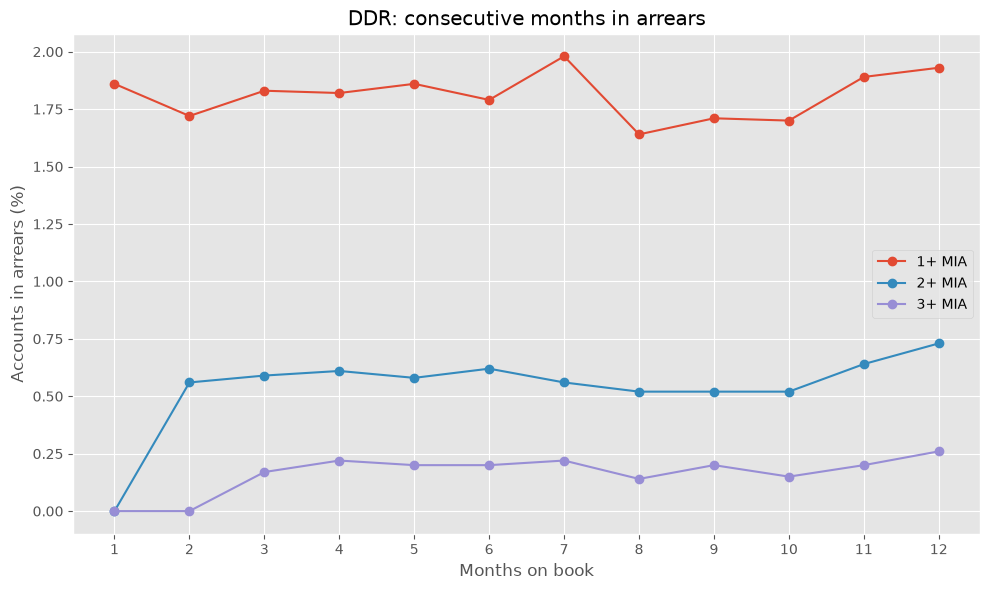

In [28]:
payment_columns = [f"missed_payment_m{i:02d}" for i in range(1, 13)]

# Calculate each account's consecutive months in arrears at each month on book.
consecutive_mia_by_month = pd.DataFrame(
    index=performance.index,
    columns=payment_columns,
    dtype=int,
)

for row_index, row in performance[payment_columns].iterrows():
    current_mia = 0

    for column in payment_columns:
        if row[column] == 1:
            current_mia += 1
        else:
            # A paid month cures the account and resets consecutive MIA to zero.
            current_mia = 0

        consecutive_mia_by_month.loc[row_index, column] = current_mia

# Percentage of all accounts at each MIA threshold, by month on book.
ddr = pd.DataFrame({
    "month_on_book": range(1, 13),
    "1+ MIA": [
        (consecutive_mia_by_month[column] >= 1).mean() * 100
        for column in payment_columns
    ],
    "2+ MIA": [
        (consecutive_mia_by_month[column] >= 2).mean() * 100
        for column in payment_columns
    ],
    "3+ MIA": [
        (consecutive_mia_by_month[column] >= 3).mean() * 100
        for column in payment_columns
    ],
}).round(2)

display(ddr)

plt.figure(figsize=(10, 6))

plt.plot(ddr["month_on_book"], ddr["1+ MIA"], marker="o", label="1+ MIA")
plt.plot(ddr["month_on_book"], ddr["2+ MIA"], marker="o", label="2+ MIA")
plt.plot(ddr["month_on_book"], ddr["3+ MIA"], marker="o", label="3+ MIA")

plt.title("DDR: consecutive months in arrears")
plt.xlabel("Months on book")
plt.ylabel("Accounts in arrears (%)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Validation points here:

1. Counts and sample size: percentages alone can conceal very few accounts. Display the number of accounts at each threshold as well.
2. Roll rates: calculate how many accounts move from 1 MIA to 2 MIA, and from 2 MIA to 3 MIA, versus cure. That reveals whether collections/cure performance is acceptable.
3. Definition: confirm that 0 truly means a customer cured arrears, rather than simply “did not miss this month.” This determines whether consecutive MIA is valid.
4. Synthetic-data realism: the relatively flat 1+ MIA rate and the absence of a strong early-vintage pattern may reflect how the synthetic data was generated, rather than believable portfolio behaviour.
5. Target choice: 2+ or 3+ consecutive MIA within 12 months may be reasonable candidate scorecard targets, but select it based on the intended underwriting use, event rate, and business definition—not from this chart alone.

In [29]:
# Build each account's consecutive-MIA position at every month.
consecutive_mia_by_month = pd.DataFrame(
    index=performance.index,
    columns=payment_columns,
    dtype=int,
)

for row_index, row in performance[payment_columns].iterrows():
    current_streak = 0

    for column in payment_columns:
        if row[column] == 1:
            current_streak += 1
        else:
            # Payment made: account cures and consecutive MIA returns to zero.
            current_streak = 0

        consecutive_mia_by_month.loc[row_index, column] = current_streak

# Percentage of the full account population at each MIA level in each month.
ddr_style_consecutive_mia = pd.DataFrame({
    "month": range(1, 13),
    "1_mia_rate_pct": [
        (consecutive_mia_by_month[column] >= 1).mean() * 100
        for column in payment_columns
    ],
    "2_mia_rate_pct": [
        (consecutive_mia_by_month[column] >= 2).mean() * 100
        for column in payment_columns
    ],
    "3_mia_rate_pct": [
        (consecutive_mia_by_month[column] >= 3).mean() * 100
        for column in payment_columns
    ],
}).round(2)

ddr_style_consecutive_mia

,month,1_mia_rate_pct,2_mia_rate_pct,3_mia_rate_pct
0,1,1.86,0.00,0.00
1,2,1.72,0.56,0.00
2,3,1.83,0.59,0.17
3,4,1.82,0.61,0.22
4,5,1.86,0.58,0.20
5,6,1.79,0.62,0.20
6,7,1.98,0.56,0.22
7,8,1.64,0.52,0.14
8,9,1.71,0.52,0.20
9,10,1.70,0.52,0.15


---
# Experian datasets

## Profiling - viewing the datasets

In [30]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")

experian = pd.read_csv(DATA_DIR / "experian_consumer.csv")

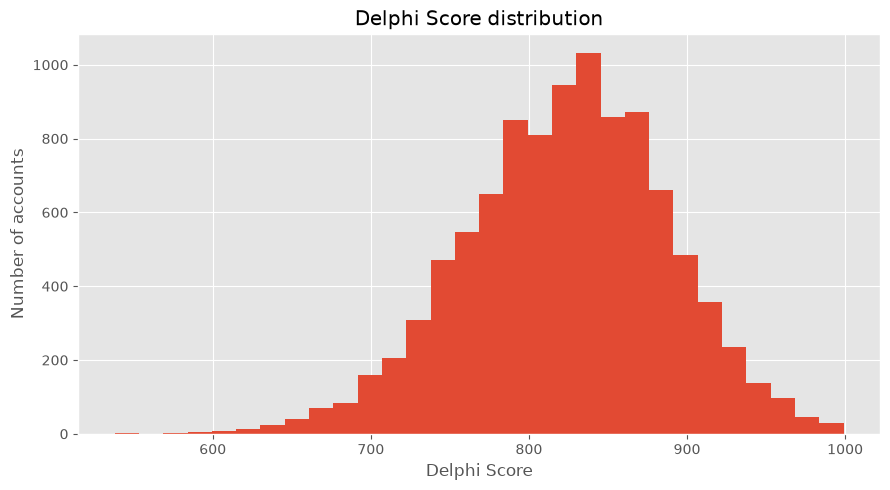

In [31]:
plt.figure(figsize=(9, 5))

plt.hist(experian["DelphiScore"], bins=30)
plt.title("Delphi Score distribution")
plt.xlabel("Delphi Score")
plt.ylabel("Number of accounts")

plt.tight_layout()
plt.show()

In [32]:
experian = pd.read_csv(DATA_DIR / "experian_consumer.csv")
experian_dictionary = pd.read_csv(
    DATA_DIR / "experian_consumer_dictionary.csv"
)

print("Experian consumer data:")
display(experian.head())

print("\nExperian field dictionary:")
display(experian_dictionary.head())

Experian consumer data:


,account_id,DelphiScore,E1A04,E1A09,E1B01,E1B07,E1B09,E1B12,E1B13,E1E01,E1E02,E1A01,E1A02,EA1C01,EA4Q01
0,ACC-10000000,825,0,0,1,0,5,1,0,1,1,0,0,N,N
1,ACC-10000001,871,0,0,2,0,3,1,0,2,3,0,0,N,N
2,ACC-10000002,881,0,0,1,0,1,0,0,2,2,0,0,N,N
3,ACC-10000003,800,0,1,0,1,2,0,0,0,1,0,0,N,N
4,ACC-10000004,841,0,1,2,1,2,0,0,2,2,0,0,N,T



Experian field dictionary:


,field,schema_meaning,schema_type_or_range,source,teaching_note
0,account_id,Project linkage identifier; not an Experian field,string,RT-Howe/corezoid_poc Delphi Select v2 Consumer...,Schema-aligned field; generated values are syn...
1,DelphiScore,Delphi score,integer,RT-Howe/corezoid_poc Delphi Select v2 Consumer...,Schema-aligned field; generated values are syn...
2,E1A04,Number of default CAIS accounts excluding mail...,integer code: -1 to 9,RT-Howe/corezoid_poc Delphi Select v2 Consumer...,Schema-aligned field; generated values are syn...
3,E1A09,Number of delinquent CAIS accounts excluding m...,integer code: -1 to 9,RT-Howe/corezoid_poc Delphi Select v2 Consumer...,Schema-aligned field; generated values are syn...
4,E1B01,Number of active CAIS accounts opened in the l...,integer code: -1 to 9,RT-Howe/corezoid_poc Delphi Select v2 Consumer...,Schema-aligned field; generated values are syn...


## Data Quality and Orientation for Experian consumer data

In [33]:
# Keep only the account identifier and Delphi score.
delphi = experian[["account_id", "DelphiScore"]].copy()

print("DELPHI SCORE: PROFILE")
print("=" * 50)

# Structure
print(f"\nRows: {len(delphi):,}")
print(f"Unique account IDs: {delphi['account_id'].nunique():,}")

# Data quality
print("\n--- Data quality checks ---")
print(f"Missing account IDs: {delphi['account_id'].isna().sum():,}")
print(f"Duplicate account IDs: {delphi['account_id'].duplicated().sum():,}")
print(f"Missing Delphi scores: {delphi['DelphiScore'].isna().sum():,}")
print(f"Duplicate full rows: {delphi.duplicated().sum():,}")

# Descriptive statistics
print("\n--- Delphi score descriptive statistics ---")
display(
    delphi["DelphiScore"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame("DelphiScore")
    .round(2)
)

# Distribution across score bands
delphi["score_band"] = pd.cut(
    delphi["DelphiScore"],
    bins=[0, 500, 600, 700, 800, 900, float("inf")],
    labels=["≤500", "501–600", "601–700", "701–800", "801–900", "901+"],
    include_lowest=True,
)

print("\n--- Score-band distribution ---")
score_bands = delphi["score_band"].value_counts(sort=False).to_frame("accounts")
score_bands["percentage"] = (score_bands["accounts"] / len(delphi) * 100).round(2)
display(score_bands)

# Lowest and highest scores for a quick plausibility check
print("\n--- Lowest 10 scores ---")
display(delphi.nsmallest(10, "DelphiScore"))

print("\n--- Highest 10 scores ---")
display(delphi.nlargest(10, "DelphiScore"))

DELPHI SCORE: PROFILE

Rows: 10,000
Unique account IDs: 10,000

--- Data quality checks ---
Missing account IDs: 0
Duplicate account IDs: 0
Missing Delphi scores: 0
Duplicate full rows: 0

--- Delphi score descriptive statistics ---


,DelphiScore
count,10000.00
mean,823.50
std,64.04
min,538.00
1%,662.00
5%,715.00
25%,781.00
50%,827.00
75%,867.00
95%,924.00



--- Score-band distribution ---


,accounts,percentage
score_band,,
≤500,0,0.00
501–600,10,0.10
601–700,323,3.23
701–800,3156,31.56
801–900,5405,54.05
901+,1106,11.06



--- Lowest 10 scores ---


,account_id,DelphiScore,score_band
1123,ACC-10001123,538,501–600
4672,ACC-10004672,551,501–600
4947,ACC-10004947,581,501–600
7965,ACC-10007965,583,501–600
7694,ACC-10007694,587,501–600
8033,ACC-10008033,591,501–600
875,ACC-10000875,592,501–600
2373,ACC-10002373,595,501–600
5510,ACC-10005510,596,501–600
7853,ACC-10007853,600,501–600



--- Highest 10 scores ---


,account_id,DelphiScore,score_band
329,ACC-10000329,999,901+
970,ACC-10000970,999,901+
1034,ACC-10001034,999,901+
1276,ACC-10001276,999,901+
1636,ACC-10001636,999,901+
2739,ACC-10002739,999,901+
4321,ACC-10004321,999,901+
4330,ACC-10004330,999,901+
5301,ACC-10005301,999,901+
6359,ACC-10006359,999,901+


---

# Next Steps

1. Data write up on any join difficulties that I forsee - i.e. many to one joins for application ID + Identify any unmatched rows i.e. applications in one but not another and come up with solution!
2. Write up on portfolio from graphs
3. Data cleaning i.e. removing duplicates and assessing blanks
4. Design linkage solution

# Question for AI

- give me a few examples of performance targets and how do i build a linked modelling dataset

- Run through cleaning of tables etc

- deciding on a target definition for the dataset